In [0]:
# 1. IMPORTS
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.neighbors import NearestNeighbors

plt.rcParams["figure.figsize"] = (10, 6)
sns.set_style("whitegrid")
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)

In [0]:
# 2. CONFIG
TABLE_NAME = "workspace.instagram.instagram_extract_data_v_3"
USE_SAMPLE = False
SAMPLE_N = 50000

# KNN configuration
N_NEIGHBORS = 1
DISTANCE_METRIC = "euclidean"

In [0]:
# 3. LOAD DATA
df_spark = spark.table(TABLE_NAME)

if USE_SAMPLE:
    df_spark = df_spark.limit(SAMPLE_N)

df = df_spark.toPandas().copy()

print("Data loaded successfully")
print("Shape:", df.shape)
print("\nPreview:")
display(df.head())

Data loaded successfully
Shape: (100000, 54)

Preview:


user_id,age,gender,location_tier,device_type,account_age_days,is_creator,follower_count_band,language_pref,past_engagement_score,avg_daily_time_spent_min,avg_sessions_per_day,active_days_last_30,historical_ctr,historical_cvr,historical_save_rate,historical_share_rate,past_purchases_count,preferred_content_type,historical_video_watch_rate,historical_ad_engagement_rate,true_propensity,treatment_flag,campaign_id,ad_format,campaign_objective,creative_theme,cta_type,discount_flag,personalization_flag,placement_quality_score,hour_bucket,day_of_week,is_weekend,auction_competitiveness,cost_per_impression,impressions,reach,frequency,clicks,likes,comments,shares,saves,profile_visits,video_views,avg_watch_time_sec,landing_page_views,conversion_prob_latent,conversions,add_to_cart,revenue,time_to_convert_min,group_label
0,56,Male,Tier3,Android,1851,0,Low,Hindi,47.221247362569500,39.226017587120920,2.5436390166412430,22,0.027807313001519860,0.0179810609685922000,0.011344853744961953,0.0114219779910295410,0,Feed,0.44832902818332710,0.035698462464235324,0.050527212454546895,0,Camp_B,Reel,Traffic,Lifestyle,Shop Now,1,0,0.52611557518854660,Evening,Mon,0,0.391452872649634130,0.0185276042002003420,29,26,1.1153846153846154,2,12,0,2,3,1,13,32.2700811380586600,2,0.016859445744634355,0,0,0E-16,null,Control
1,46,Female,Tier2,iOS,1906,1,Low,Hindi,53.628004139051010,50.136434241890754,2.9090505494058334,22,0.036551984772101066,0.0172793514126130080,0.020207778973479355,0.0118099043270579100,1,Reel,0.38548591179464414,0.042435354998116875,0.082895535773053490,0,Camp_B,Feed,Awareness,UGC,Learn More,1,1,0.41072219264409170,Morning,Sun,1,0.582320021969901600,0.0169268546752867170,33,25,1.3200000000000000,3,11,2,1,4,0,14,31.7788186354596930,1,0.026830404389953377,0,0,0E-16,null,Control
2,32,Male,Tier3,Android,1115,0,Low,Tamil,43.559289805692580,43.885266797058115,2.0758501180321560,18,0.031517022672127350,0.0159907283754884500,0.017594059009578382,0.0098276063550271250,0,Story,0.37374131460355703,0.036847280418297120,0.031791042476430930,0,Camp_B,Carousel,Traffic,Lifestyle,Sign Up,0,0,0.53420796356520310,Evening,Sat,1,0.513181455513167700,0.0190582816962745100,22,15,1.4666666666666666,1,5,2,3,4,0,14,18.6198912986014380,1,0.016160486732534434,0,0,0E-16,null,Control
3,25,Male,Tier2,Android,1560,0,Low,Tamil,49.476851087883330,54.951579910132350,2.3862473044634376,21,0.030691132740128597,0.0148301590331351080,0.017909000344826547,0.0088788524905082330,0,Reel,0.40802514265843050,0.038152473065200340,0.041759502501747490,0,Camp_C,Reel,Conversion,Lifestyle,Learn More,1,1,0.35548293266326030,Night,Fri,0,0.572276951051262700,0.0258487349324747380,21,16,1.3125000000000000,1,9,4,0,2,1,7,33.0288916140230000,1,0.022602436376481707,0,0,0E-16,null,Control
4,38,Male,Tier3,Android,927,0,High,English,56.060770155689470,58.254233569980930,3.1838385248207260,19,0.033676630946453700,0.0177409207940187050,0.019671295233881933,0.0136671176427728930,0,Story,0.38566699295302910,0.046839438232036770,0.070668060594261490,0,Camp_A,Feed,Awareness,Offer,Sign Up,0,0,0.41151374498107357,Evening,Thu,0,0.623646972433834000,0.0156071290469612930,32,22,1.4545454545454546,0,7,0,2,7,0,7,38.4440337705984940,0,0.018445757043904480,0,0,0E-16,null,Control


In [0]:
# 4. BASIC CHECKS
required_cols = ["user_id", "treatment_flag", "conversions"]
missing_required = [c for c in required_cols if c not in df.columns]

if missing_required:
    raise ValueError(f"Missing required columns: {missing_required}")

print("\nTreatment split:")
display(
    df["treatment_flag"]
    .value_counts(dropna=False)
    .rename_axis("treatment_flag")
    .reset_index(name="count")
)

print("\nRaw conversion summary:")
raw_conv = (
    df.groupby("treatment_flag")["conversions"]
    .agg(["count", "mean", "sum"])
    .reset_index()
    .rename(columns={"mean": "conversion_rate", "sum": "total_conversions"})
)
display(raw_conv.round(4))



Treatment split:


treatment_flag,count
0,94600
1,5400



Raw conversion summary:


treatment_flag,count,conversion_rate,total_conversions
0,94600,0.024,2269
1,5400,0.0344,186


In [0]:
# 5. SELECT TRUE BASELINE / PRE-TREATMENT VARIABLES ONLY
candidate_match_cols = [
    "age",
    "gender",
    "location_tier",
    "device_type",
    "account_age_days",
    "is_creator",
    "follower_count_band",
    "language_pref",
    "past_engagement_score"
]

match_cols = [c for c in candidate_match_cols if c in df.columns]

if len(match_cols) == 0:
    raise ValueError("No baseline matching columns found in the table.")

print("\nMatching columns used:")
print(match_cols)

work_df = df[["user_id", "treatment_flag", "conversions"] + match_cols].copy()

before_drop = len(work_df)
work_df = work_df.dropna(subset=match_cols).reset_index(drop=True)
after_drop = len(work_df)

print(f"\nRows before dropna: {before_drop}")
print(f"Rows after dropna : {after_drop}")
print(f"Rows dropped      : {before_drop - after_drop}")


Matching columns used:
['age', 'gender', 'location_tier', 'device_type', 'account_age_days', 'is_creator', 'follower_count_band', 'language_pref', 'past_engagement_score']

Rows before dropna: 100000
Rows after dropna : 100000
Rows dropped      : 0


In [0]:
# 6. IDENTIFY NUMERIC / CATEGORICAL COLUMNS
numeric_cols = work_df[match_cols].select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = [c for c in match_cols if c not in numeric_cols]

print("\nNumeric baseline columns:")
print(numeric_cols)

print("\nCategorical baseline columns:")
print(categorical_cols)


Numeric baseline columns:
['age', 'account_age_days', 'is_creator']

Categorical baseline columns:
['gender', 'location_tier', 'device_type', 'follower_count_band', 'language_pref', 'past_engagement_score']


In [0]:
# 7. PREPROCESS FEATURES
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

X_all = work_df[match_cols].copy()
X_processed = preprocessor.fit_transform(X_all)

print("\nProcessed feature matrix shape:", X_processed.shape)


Processed feature matrix shape: (100000, 100000)


In [0]:
# 8. SPLIT TEST / CONTROL
test_mask = work_df["treatment_flag"].values == 1
control_mask = work_df["treatment_flag"].values == 0

test_df = work_df[test_mask].copy().reset_index(drop=True)
control_df = work_df[control_mask].copy().reset_index(drop=True)

X_test = X_processed[test_mask]
X_control = X_processed[control_mask]

print("\nSample sizes")
print("Test   :", len(test_df))
print("Control:", len(control_df))
print("X_test shape   :", X_test.shape)
print("X_control shape:", X_control.shape)


Sample sizes
Test   : 5400
Control: 94600
X_test shape   : (5400, 100000)
X_control shape: (94600, 100000)


In [0]:
# 9. PURE KNN MATCHING
#    1:1, WITH REPLACEMENT
knn = NearestNeighbors(
    n_neighbors=N_NEIGHBORS,
    metric=DISTANCE_METRIC
)
knn.fit(X_control)
distances, indices = knn.kneighbors(X_test)
matched_pairs = []
for i, (dist_row, idx_row) in enumerate(zip(distances, indices)):
    test_row = test_df.iloc[i]
    control_row = control_df.iloc[idx_row[0]]
    matched_pairs.append({
        "test_user_id": test_row["user_id"],
        "control_user_id": control_row["user_id"],
        "distance_knn": dist_row[0]
    })
matched_pairs_df = pd.DataFrame(matched_pairs)
print("\nKNN Matching complete")
matched_test_count = matched_pairs_df["test_user_id"].nunique() if len(matched_pairs_df) > 0 else 0
matched_control_count = matched_pairs_df["control_user_id"].nunique() if len(matched_pairs_df) > 0 else 0

print("Total test users      :", len(test_df))
print("Matched test users    :", matched_test_count)
print("Matched control users :", matched_control_count)
print("Unmatched test users  :", len(test_df) - matched_test_count)
print("Matched pair rows     :", len(matched_pairs_df))

if len(matched_pairs_df) > 0:
    display(matched_pairs_df.head(10))
else:
    raise ValueError("No matches found in KNN step.")


KNN Matching complete
Total test users      : 5400
Matched test users    : 5400
Matched control users : 5183
Unmatched test users  : 0
Matched pair rows     : 5400


test_user_id,control_user_id,distance_knn
5,5653,1.4146930496051873
33,36824,1.423994041257737
34,82665,1.418822598890233
66,37011,1.4142668467600374
106,19374,1.4144919239582512
115,51798,1.415065871793002
124,56252,1.415191935205923
140,46601,1.4142831579057207
146,55064,1.414648478279539
172,75014,1.4391342770367626


In [0]:
# 10. BUILD MATCHED DATASET
matched_test_df = test_df.merge(
    matched_pairs_df[["test_user_id"]],
    left_on="user_id",
    right_on="test_user_id",
    how="inner"
).drop(columns=["test_user_id"])

matched_control_df = control_df.merge(
    matched_pairs_df[["control_user_id"]],
    left_on="user_id",
    right_on="control_user_id",
    how="inner"
).drop(columns=["control_user_id"])
matched_df = pd.concat([matched_test_df, matched_control_df], axis=0).reset_index(drop=True)

print("\nMatched dataset shape:", matched_df.shape)
print("\nMatched treatment split:")
display(
    matched_df["treatment_flag"]
    .value_counts()
    .rename_axis("treatment_flag")
    .reset_index(name="count")
)


Matched dataset shape: (10800, 12)

Matched treatment split:


treatment_flag,count
1,5400
0,5400



Sample summary:


dataset,group,count
original,control,94600
original,test,5400
matched,control,5400
matched,test,5400


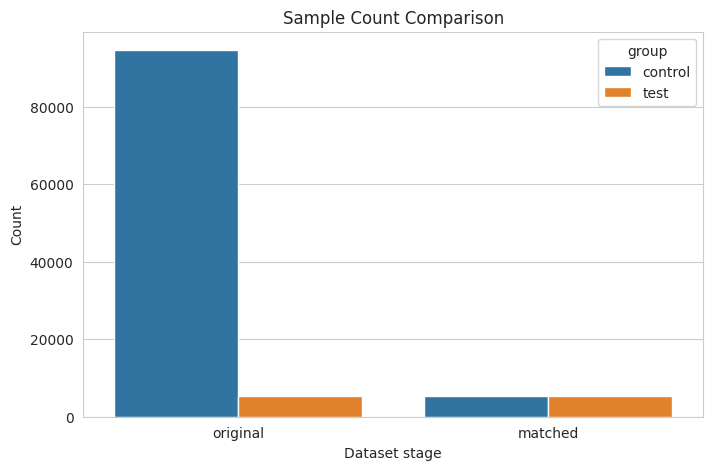

In [0]:
# 11. SAMPLE COUNT COMPARISON
sample_summary = pd.DataFrame({
    "dataset": ["original", "original", "matched", "matched"],
    "group": ["control", "test", "control", "test"],
    "count": [
        (work_df["treatment_flag"] == 0).sum(),
        (work_df["treatment_flag"] == 1).sum(),
        (matched_df["treatment_flag"] == 0).sum(),
        (matched_df["treatment_flag"] == 1).sum(),
    ]
})
print("\nSample summary:")
display(sample_summary)

plt.figure(figsize=(8, 5))
sns.barplot(data=sample_summary, x="dataset", y="count", hue="group")
plt.title("Sample Count Comparison")
plt.xlabel("Dataset stage")
plt.ylabel("Count")
plt.show()


Balance comparison:


feature,pre_smd,abs_pre_smd,post_smd,abs_post_smd
account_age_days,0.1051,0.1051,0.0017,0.0017
is_creator,0.0948,0.0948,0.0,0.0
age,-0.0048,0.0048,4.0E-4,4.0E-4


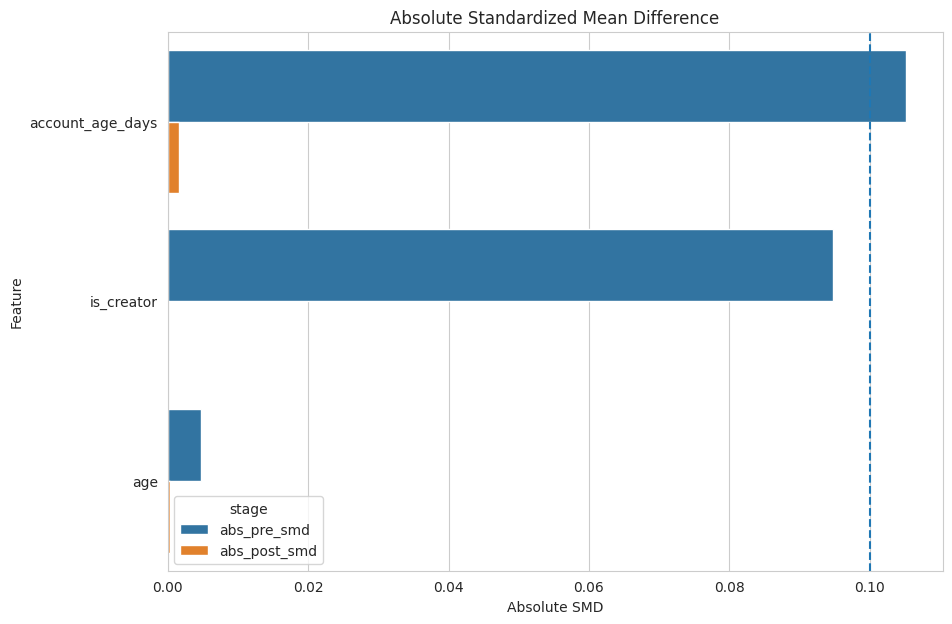

In [0]:
# 12. BALANCE CHECK — STANDARDIZED MEAN DIFFERENCE (NUMERIC)
# ============================================================
def calc_numeric_smd(data, treatment_col, feature_cols):
    treated = data[data[treatment_col] == 1]
    control = data[data[treatment_col] == 0]
    rows = []

    for col in feature_cols:
        mean_t = treated[col].mean()
        mean_c = control[col].mean()
        std_t = treated[col].std()
        std_c = control[col].std()

        pooled_std = np.sqrt((std_t**2 + std_c**2) / 2)

        if pooled_std == 0 or np.isnan(pooled_std):
            smd = 0.0
        else:
            smd = (mean_t - mean_c) / pooled_std

        rows.append({
            "feature": col,
            "treated_mean": mean_t,
            "control_mean": mean_c,
            "smd": smd,
            "abs_smd": abs(smd)
        })

    return pd.DataFrame(rows)

balance_pre = calc_numeric_smd(work_df, "treatment_flag", numeric_cols)[["feature", "smd", "abs_smd"]]
balance_pre = balance_pre.rename(columns={"smd": "pre_smd", "abs_smd": "abs_pre_smd"})

balance_post = calc_numeric_smd(matched_df, "treatment_flag", numeric_cols)[["feature", "smd", "abs_smd"]]
balance_post = balance_post.rename(columns={"smd": "post_smd", "abs_smd": "abs_post_smd"})

balance_compare = balance_pre.merge(balance_post, on="feature", how="outer")
balance_compare = balance_compare.sort_values("abs_pre_smd", ascending=False).reset_index(drop=True)

print("\nBalance comparison:")
display(balance_compare.round(4))

plot_balance = balance_compare.melt(
    id_vars="feature",
    value_vars=["abs_pre_smd", "abs_post_smd"],
    var_name="stage",
    value_name="abs_smd"
)

plt.figure(figsize=(10, 7))
sns.barplot(data=plot_balance, y="feature", x="abs_smd", hue="stage")
plt.axvline(0.10, linestyle="--")
plt.title("Absolute Standardized Mean Difference")
plt.xlabel("Absolute SMD")
plt.ylabel("Feature")
plt.show()

In [0]:
# 13. CATEGORICAL BALANCE SNAPSHOT
for c in categorical_cols[:8]:
    print(f"\nCategorical balance — {c} (PRE-MATCH)")
    pre_tab = pd.crosstab(work_df[c], work_df["treatment_flag"], normalize="columns") * 100
    display(pre_tab.round(2))

    print(f"Categorical balance — {c} (POST-MATCH)")
    post_tab = pd.crosstab(matched_df[c], matched_df["treatment_flag"], normalize="columns") * 100
    display(post_tab.round(2))



Categorical balance — gender (PRE-MATCH)


0,1
48.08,48.85
51.92,51.15


Categorical balance — gender (POST-MATCH)


0,1
48.85,48.85
51.15,51.15



Categorical balance — location_tier (PRE-MATCH)


...

0,1
34.44,34.44
30.76,30.76
14.06,14.06
20.74,20.74



Categorical balance — past_engagement_score (PRE-MATCH)


0,1
0.0,0.0
0.0,0.0
0.0,0.0
0.0,0.0
0.0,0.0
0.0,0.0
0.0,0.0
0.0,0.0
0.0,0.0
0.0,0.0


Categorical balance — past_engagement_score (POST-MATCH)


0,1
0.02,0.0
0.0,0.02
0.02,0.0
0.02,0.0
0.0,0.02
0.0,0.02
0.02,0.0
0.02,0.0
0.02,0.0
0.0,0.02


In [0]:
# 14. CONVERSION SUMMARY — ORIGINAL / MATCHED
def conversion_summary_fn(data, label):
    out = (
        data.groupby("treatment_flag")["conversions"]
        .agg(["count", "mean", "sum"])
        .reset_index()
        .rename(columns={"mean": "conversion_rate", "sum": "total_conversions"})
    )
    out["dataset"] = label
    return out

orig_conv = conversion_summary_fn(work_df, "original")
matched_conv = conversion_summary_fn(matched_df, "matched")

print("\nOriginal conversion summary:")
display(orig_conv.round(4))
print("\nMatched conversion summary:")
display(matched_conv.round(4))


Original conversion summary:


treatment_flag,count,conversion_rate,total_conversions,dataset
0,94600,0.024,2269,original
1,5400,0.0344,186,original



Matched conversion summary:


treatment_flag,count,conversion_rate,total_conversions,dataset
0,5400,0.0243,131,matched
1,5400,0.0344,186,matched


In [0]:
# 15. LIFT SUMMARY
def build_lift_summary(summary_df, dataset_name):
    control_rate = summary_df.loc[summary_df["treatment_flag"] == 0, "conversion_rate"].values[0]
    test_rate = summary_df.loc[summary_df["treatment_flag"] == 1, "conversion_rate"].values[0]
    absolute_lift = test_rate - control_rate
    relative_lift = (test_rate / control_rate - 1) if control_rate > 0 else np.nan
    return pd.DataFrame({
        "dataset": [dataset_name],
        "control_rate": [control_rate],
        "test_rate": [test_rate],
        "absolute_lift": [absolute_lift],
        "relative_lift": [relative_lift]
    })

lift_original = build_lift_summary(orig_conv, "original")
lift_matched = build_lift_summary(matched_conv, "matched")
lift_summary = pd.concat([lift_original, lift_matched], axis=0)

print("\nLift summary:")
display(lift_summary.round(4))



Lift summary:


dataset,control_rate,test_rate,absolute_lift,relative_lift
original,0.024,0.0344,0.0105,0.4361
matched,0.0243,0.0344,0.0102,0.4198


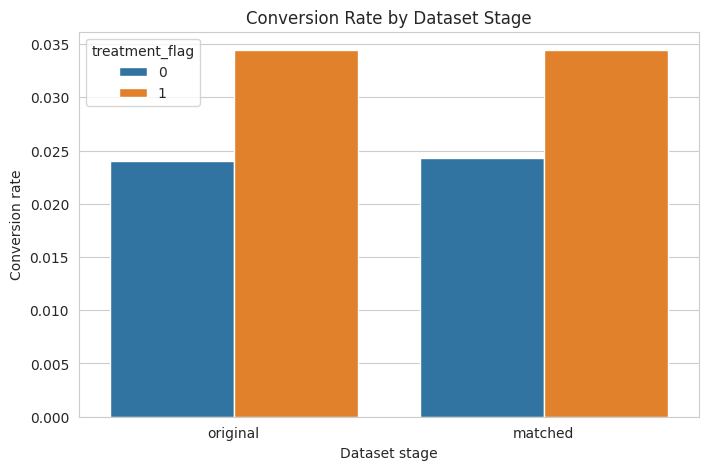

In [0]:
# 16. VISUALIZE CONVERSION RATES
plot_conv = pd.concat([orig_conv, matched_conv], axis=0)
plt.figure(figsize=(8, 5))
sns.barplot(data=plot_conv, x="dataset", y="conversion_rate", hue="treatment_flag")
plt.title("Conversion Rate by Dataset Stage")
plt.xlabel("Dataset stage")
plt.ylabel("Conversion rate")
plt.show()


Match distance summary:


metric,count,mean,std,min,25%,50%,75%,max
distance_knn,5400.0,1.419556,0.016293,1.414214,1.414566,1.41663,1.418362,1.895309


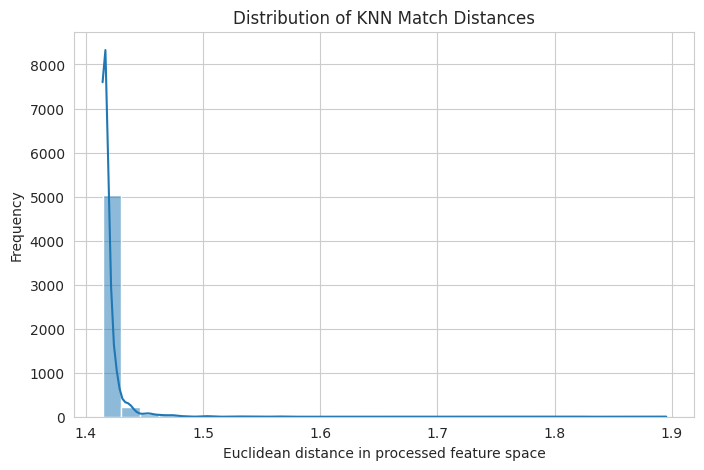

In [0]:
# 17. MATCH DISTANCE DIAGNOSTICS
print("\nMatch distance summary:")
distance_summary = (
    matched_pairs_df[["distance_knn"]]
    .describe()
    .T
    .reset_index()
    .rename(columns={"index": "metric"})
)
display(distance_summary.round(6))

plt.figure(figsize=(8, 5))
sns.histplot(matched_pairs_df["distance_knn"], bins=30, kde=True)
plt.title("Distribution of KNN Match Distances")
plt.xlabel("Euclidean distance in processed feature space")
plt.ylabel("Frequency")
plt.show()

In [0]:
# 18. SAVE OUTPUTS
matched_analysis_df = df.merge(
    matched_df[["user_id"]],
    on="user_id",
    how="inner"
)
print("\nMatched analysis dataset shape:", matched_analysis_df.shape)


Matched analysis dataset shape: (10800, 54)


In [0]:
# 19. FINAL SUMMARY
print("Method                         : Pure KNN Matching on Baseline Features")
print(f"Original rows                  : {len(work_df)}")
print(f"Matched rows                   : {len(matched_df)}")
print("Matching type                  : 1:1 KNN on baseline features")
print("Replacement                    : Yes (implicit)")

Method                         : Pure KNN Matching on Baseline Features
Original rows                  : 100000
Matched rows                   : 10800
Matching type                  : 1:1 KNN on baseline features
Replacement                    : Yes (implicit)
